In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(100)

Make a synthetic generation profile

Text(0.5, 1.0, 'Demand')

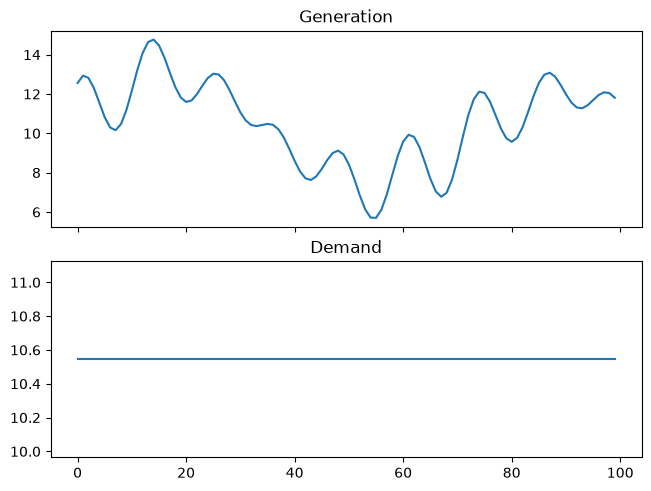

In [ ]:




n_sins = 5

n_points = 100


amplitudes = 3 * np.random.rand(n_sins)
periods = 10 * 2 * np.pi / n_points * np.random.rand(n_sins)
phases = 2 * np.pi * np.random.rand(n_sins)

mean = 10

generation = mean * np.ones(n_points)



time = np.arange(0, n_points, 1)

for i in range(n_sins):
    generation += amplitudes[i] * np.sin(periods[i] * time + phases[i])



demand = np.mean(generation) * np.ones(n_points)


fig, ax = plt.subplots(2, 1, sharex="all", sharey="all", layout="constrained")

ax[0].plot(time, generation)
ax[1].plot(time, demand)

ax[0].set_title("Generation")
ax[1].set_title("Demand")



Storage needs to cover the difference between generation and demand

Charging/discharging = generation - demand

Text(0.5, 1.0, 'Charge state')

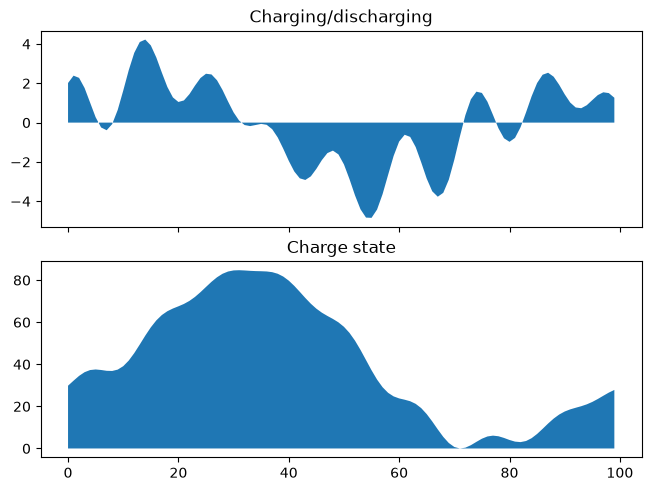

In [14]:
charging = generation - demand
soc = np.cumsum(charging)

soc = soc - np.min(soc)

fig, ax = plt.subplots(2, 1, sharex="all", layout="constrained")

ax[0].fill_between(time, np.zeros_like(time), charging)
ax[1].fill_between(time, np.zeros_like(time), soc)

ax[0].set_title("Charging/discharging")
ax[1].set_title("Charge state")




Required power capacity = max(abs(charging/discharging))

Required energy capcity = max(soc)


Text(0.5, 0, 'Time')

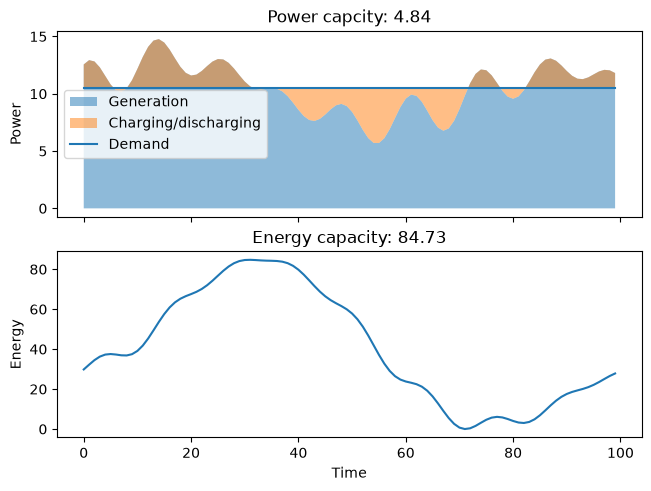

In [28]:
fig, ax = plt.subplots(2, 1, sharex="all", layout="constrained")



ax[0].fill_between(time, np.zeros_like(time),  generation, alpha=0.5, label="Generation")
ax[0].fill_between(time, generation, generation - charging, alpha=0.5, label="Charging/discharging")

# ax[0].plot(time, generation)
ax[0].plot(time, demand, label="Demand")

ax[0].set_title(f"Power capcity: {np.max(np.abs(charging)):.2f}")

ax[0].legend()

ax[1].plot(time, soc)
ax[1].set_title(f"Energy capacity: {np.max(soc):.2f}")

ax[0].set_ylabel("Power")
ax[1].set_ylabel("Energy")
ax[1].set_xlabel("Time")
